<a href="https://colab.research.google.com/github/Ven0mite/HomeworkFWE_Nelan_Remy/blob/main/Homework5_RemyNelan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install xarray netCDF4 pyproj cartopy -q

In [14]:
# Remy Nelan

!pip install xarray netCDF4 statsmodels cartopy -q
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# === DO NOT MODIFY THIS CELL — it creates the dataset ===
np.random.seed(458)

dates = pd.date_range('2018-01-01', '2024-12-31', freq='D')
n = len(dates)
doy = dates.dayofyear

# Seasonal cycle + slight warming trend + noise
seasonal = 16 * np.sin(2 * np.pi * (doy - 80) / 365)
trend = np.linspace(0, 1.5, n)
noise = np.random.normal(0, 4, n)
temperature = 8 + seasonal + trend + noise  # °C

# Precipitation (exponential with seasonal modulation)
precip_rate = 2.5 + 1.0 * np.sin(2 * np.pi * (doy - 120) / 365)
precipitation = np.random.exponential(precip_rate)  # mm

weather = pd.DataFrame({
    'date': dates,
    'temperature_c': temperature,
    'precipitation_mm': precipitation
})

# Set date as index (DatetimeIndex)
weather = weather.set_index('date')

print(f"Dataset: {len(weather)} days, {weather.index[0].date()} to {weather.index[-1].date()}")
weather.head()

Dataset: 2557 days, 2018-01-01 to 2024-12-31


,temperature_c,precipitation_mm
date,,
2018-01-01,-9.181843,0.431327
2018-01-02,-9.816574,3.576616
2018-01-03,-9.838835,3.675735
2018-01-04,-1.018871,1.621691
2018-01-05,-0.786900,1.075056


date
2018-01-31    -5.912906
2018-02-28    -1.930791
2018-03-31     5.660184
2018-04-30    15.965819
2018-05-31    19.914196
2018-06-30    23.437270
2018-07-31    22.150953
2018-08-31    16.451168
2018-09-30     9.757707
2018-10-31     1.456001
2018-11-30    -4.897208
2018-12-31    -6.698614
Freq: ME, Name: temperature_c, dtype: float64
date
2018-12-31     925.672092
2019-12-31     979.133318
2020-12-31     879.932925
2021-12-31     932.632134
2022-12-31     827.074237
2023-12-31     912.256837
2024-12-31    1048.618810
Freq: YE-DEC, Name: precipitation_mm, dtype: float64


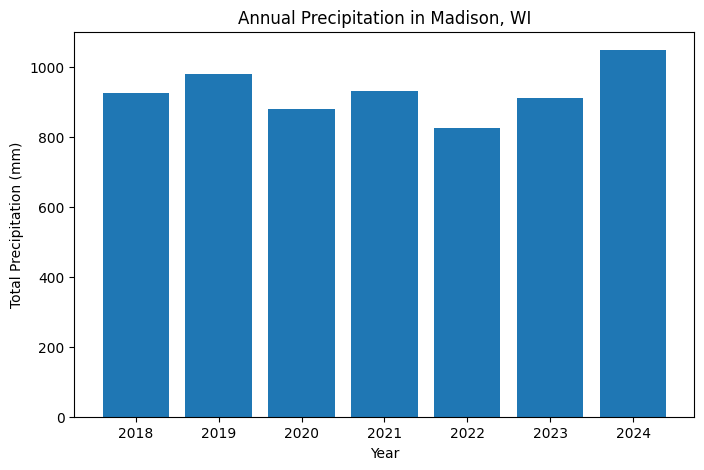

In [6]:
# Problem 1A

monthly_temp = weather['temperature_c'].resample('M').mean()
print(monthly_temp.head(12))

annual_precip = weather['precipitation_mm'].resample('Y').sum()
print(annual_precip)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(annual_precip.index.year, annual_precip.values)
ax.set_xlabel('Year')
ax.set_ylabel('Total Precipitation (mm)')
ax.set_title('Annual Precipitation in Madison, WI')
plt.show()

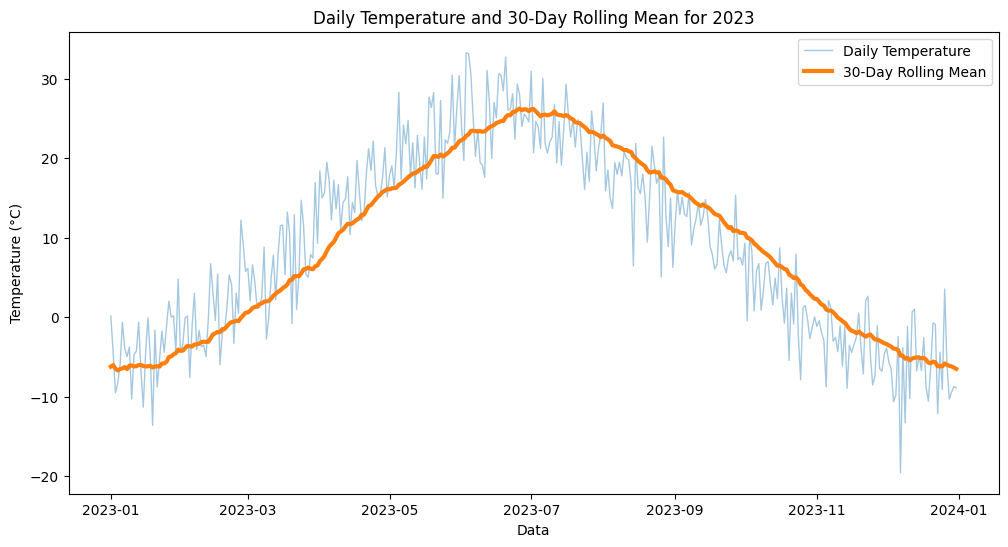

In [9]:
# Problem 1B

weather['temp_30day_ma'] = weather['temperature_c'].rolling(window=30).mean()

data2023 = weather.loc['2023']
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(data2023.index, data2023['temperature_c'], linewidth=1, alpha=0.4, label='Daily Temperature')
ax.plot(data2023.index, data2023['temp_30day_ma'], linewidth=3, label='30-Day Rolling Mean')
ax.set_xlabel('Data')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Daily Temperature and 30-Day Rolling Mean for 2023')
ax.legend()
plt.show()

<Figure size 1400x1000 with 0 Axes>

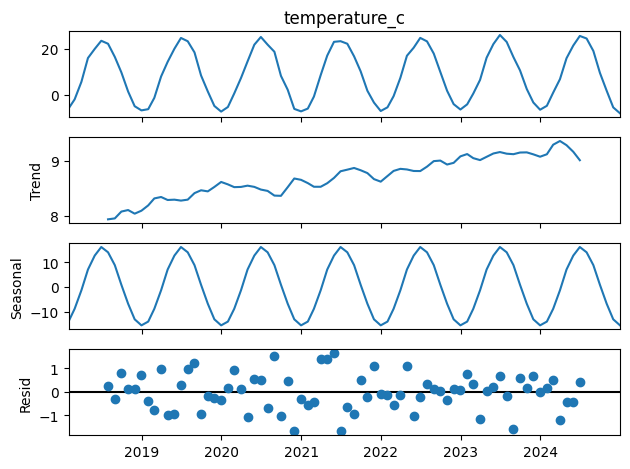

In [12]:
# Problem 1C

decomp = seasonal_decompose(monthly_temp, period=12)
fig = plt.figure(figsize=(14, 10))
decomp.plot()
plt.show()

# 1: It is increasing over the 7-year record
# 2: The range in °C is about -15 to 15 degrees for the annual temperature cycle
# 3: To be accurate to a 12 month period, rather than a 365 day period as we are analyzing months, not days.

In [17]:
# === DO NOT MODIFY THIS CELL — it loads the CRU dataset ===
cru_path = '/content/drive/MyDrive/cru_ts4.09.1901.2024.tmp.conus.nc'
ds = xr.open_dataset(cru_path)

print(f"Loaded CRU TS4.09 CONUS temperature dataset")
print(f"  Time: {pd.to_datetime(ds.time.values[0]).date()} to {pd.to_datetime(ds.time.values[-1]).date()}")
print(f"  Lat:  {float(ds.lat.min()):.2f}°N to {float(ds.lat.max()):.2f}°N")
print(f"  Lon:  {float(ds.lon.min()):.2f}° to {float(ds.lon.max()):.2f}°")
print(f"  Shape (time, lat, lon): {ds['tmp'].shape}")
ds


Loaded CRU TS4.09 CONUS temperature dataset
  Time: 1901-01-16 to 2024-12-16
  Lat:  24.75°N to 49.25°N
  Lon:  -124.75° to -66.75°
  Shape (time, lat, lon): (1488, 50, 117)


<xarray.Dataset> Size: 174MB
Dimensions:  (time: 1488, lat: 50, lon: 117)
Coordinates:
  * time     (time) datetime64[ns] 12kB 1901-01-16 1901-02-15 ... 2024-12-16
  * lat      (lat) float32 200B 24.75 25.25 25.75 26.25 ... 48.25 48.75 49.25
  * lon      (lon) float32 468B -124.8 -124.2 -123.8 ... -67.75 -67.25 -66.75
Data variables:
    tmp      (time, lat, lon) float32 35MB ...
    stn      (time, lat, lon) float64 70MB ...
    mae      (time, lat, lon) float32 35MB ...
    maea     (time, lat, lon) float32 35MB ...
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS4.09 Mean Temperature
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 2503051245. Data generated from:tmp.2503051121.dtb
    history:      CONUS subset (-125.0,24.5)-(-66.5,49.5) extracted from cru_...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Access to these data is available to any registered CEDA user.
    contact:      support@ceda.ac.uk

In [20]:
# Problem 2A

denver_temp = ds['tmp'].sel(lat=39.7, lon=-105, method='nearest')
print(denver_temp.shape)
print(denver_temp.lat.values, denver_temp.lon.values)

jan_2010 = ds['tmp'].sel(time='2010-01')
print(jan_2010.shape)

southeast = ds['tmp'].sel(
    lat=slice(25,37),
    lon=slice(-92,-75)
)
print(len(southeast.lat), len(southeast.lon))

(1488,)
39.75 -104.75
(1, 50, 117)
24 34


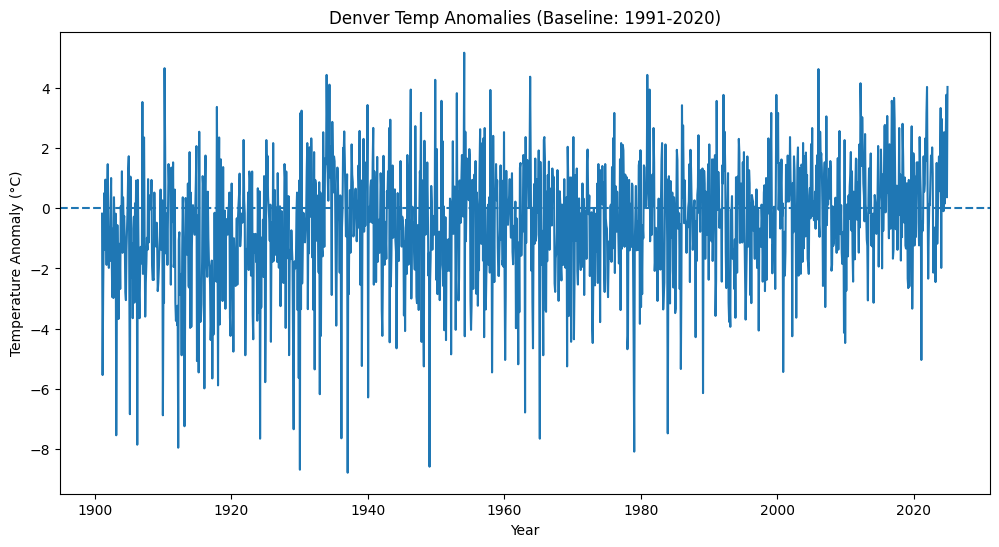

In [24]:
# Problem 2B

baseline = ds['tmp'].sel(time=slice('1991','2020'))
climatology = baseline.groupby('time.month').mean(dim='time')
anomaly = ds['tmp'].groupby('time.month') - climatology

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(denver_temp['time'], anomaly.sel(lat=denver_temp.lat, lon=denver_temp.lon, method='nearest'), label='Temp Anomaly')
ax.axhline(0, linestyle='--')
ax.set_xlabel('Year')
ax.set_ylabel('Temperature Anomaly (°C)')
ax.set_title('Denver Temp Anomalies (Baseline: 1991-2020)')
plt.show()

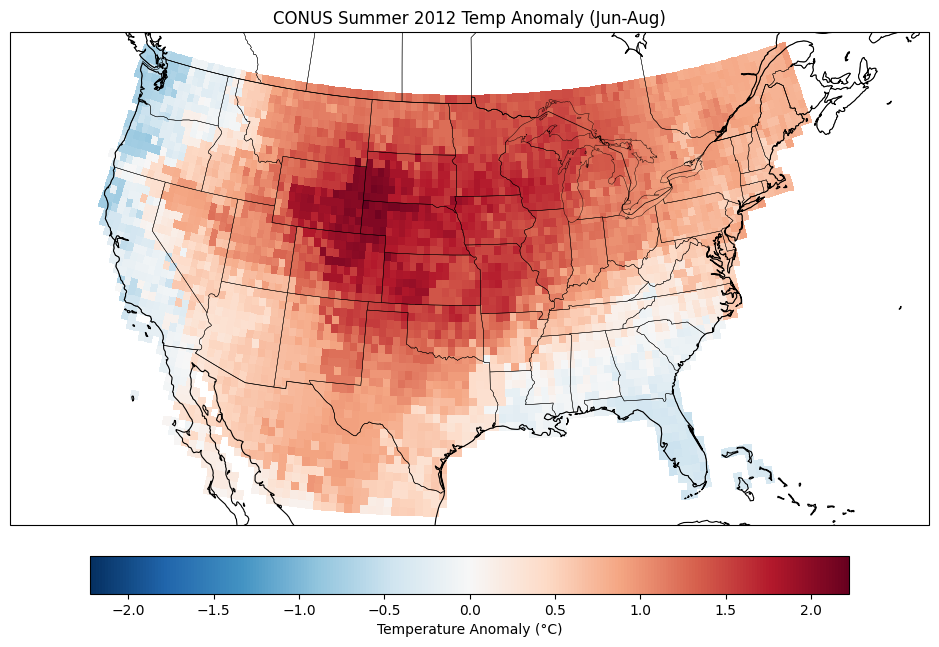

In [27]:
# Problem 2C

summer_2012 = anomaly.sel(time=slice('2012-06', '2012-08')).mean(dim='time')
import cartopy.crs as ccrs
import cartopy.feature as cfeature

projection = ccrs.LambertConformal(
    central_longitude=-96,
    central_latitude=39,
    standard_parallels=(33, 45)
)

fig, ax = plt.subplots(figsize=(14, 8), subplot_kw={'projection': projection})
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

summer_2012.plot(
    ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', center=0, cbar_kwargs={
        'label': 'Temperature Anomaly (°C)', 'shrink': 0.7, 'orientation': 'horizontal', 'pad': 0.05
    }
)

ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.STATES, linewidth=0.3)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title('CONUS Summer 2012 Temp Anomaly (Jun-Aug)')
plt.show()